In [79]:
import pandas as pd

# Cargar el CSV
df_bank = pd.read_csv('../Datos/bank-additional.csv')
print(f'Datos del CSV cargados: {df_bank.shape[0]} filas y {df_bank.shape[1]} columnas')

# Cargar el Excel (ver hojas disponibles)
# Aquí se usa el método ExcelFile() en vez de read_excel(), ya el archivo Excel contiene varias hojas, y es más eficiente usar el primer método
excel = pd.ExcelFile('../Datos/customer-details.xlsx')
print(f'Hojas disponibles en el Excel: {excel.sheet_names}')

Datos del CSV cargados: 43000 filas y 24 columnas
Hojas disponibles en el Excel: ['2012', '2013', '2014']


In [80]:
# Cargar cada hoja del Excel
#Aquí como ya tenemos toda la info con el primer método, podemos usar el read_excel
df_2012 = pd.read_excel(excel, sheet_name=excel.sheet_names[0])
df_2013 = pd.read_excel(excel, sheet_name=excel.sheet_names[1])
df_2014 = pd.read_excel(excel, sheet_name=excel.sheet_names[2])

print(f"Hoja {excel.sheet_names[0]} cargada: {df_2012.shape[0]} filas y {df_2012.shape[1]} columnas")
print(f"Hoja {excel.sheet_names[1]} cargada: {df_2013.shape[0]} filas y {df_2013.shape[1]} columnas")
print(f"Hoja {excel.sheet_names[2]} cargada: {df_2014.shape[0]} filas y {df_2014.shape[1]} columnas")

Hoja 2012 cargada: 20115 filas y 7 columnas
Hoja 2013 cargada: 8965 filas y 7 columnas
Hoja 2014 cargada: 14090 filas y 7 columnas


# Info básica del archivo CSV

In [81]:
# Con esto podemos ver cuantos elementos no nulos hay en cada columna, muy útil
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non-null 

In [82]:
# Aquí se desglosa info sobre los campos cuantitativos con algunos de sus estadísticos más importantes
df_bank.describe()

,Unnamed: 0,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


## Eliminar aquellas tuplas donde alguno de sus elementos sea nulo y donde alguna de sus columnas o llaves tenga un 2% de valores nulos o menos

In [ ]:
# #Vemos que la cantidad total de elementos nulos y no nulos por columna es de 43000 
num_filas = df_bank 

print('ANTIGUO')
print()

for clave, valor in df_bank.isnull().sum().items():
    porcentaje = int(valor)/len(num_filas)
    print(f'{clave} : {porcentaje}')

print('Nuevo')
print() 

# 1. Calcular el porcentaje de valores nulos por columna
porcentaje_nulos = df_bank.isnull().sum() / len(df_bank)

# 2. Identificar las columnas que tienen un 2% o menos de valores nulos
columnas_a_limpiar = porcentaje_nulos[porcentaje_nulos <= 0.02].index.tolist()
print('Columnas con menos del 2% de nulos (se limpiarán):', columnas_a_limpiar)

# 3. Crear una máscara booleana para encontrar filas con nulos SOLO en las columnas a limpiar
# np.any() con axis=1 comprueba si hay algún valor True (nulo) a lo largo de las filas
mascara_nulos = df_bank[columnas_a_limpiar].isnull().any(axis=1)

# 4. Eliminar las filas que cumplen la condición de la máscara
filas_antes = len(df_bank)
df_bank_limpio = df_bank[~mascara_nulos].copy() # El símbolo ~ invierte la máscara (True a False, y viceversa)
filas_despues = len(df_bank_limpio)

print(f'\nFilas antes de la limpieza: {filas_antes}')
print(f'Filas después de la limpieza: {filas_despues}')
print(f'Filas eliminadas: {filas_antes - filas_despues}')

# 5. Verificar que las columnas limpiadas no tengan nulos, mientras que el resto sí pueden tenerlos
print('\nVerificación de nulos después de la limpieza:')
print(df_bank_limpio.isnull().sum())

#Se han borrado un 2.5% de los datos (esto es debido a que varias columnas tenían menos de un 2% de datos nulos). Asumible, el EDA no debería verse afectado. 

ANTIGUO

Unnamed: 0 : 0.0
age : 0.11906976744186047
job : 0.008023255813953488
marital : 0.0019767441860465114
education : 0.04202325581395349
default : 0.20886046511627906
housing : 0.02386046511627907
loan : 0.02386046511627907
contact : 0.0
duration : 0.0
campaign : 0.0
pdays : 0.0
previous : 0.0
poutcome : 0.0
emp.var.rate : 0.0
cons.price.idx : 0.010953488372093024
cons.conf.idx : 0.0
euribor3m : 0.21525581395348836
nr.employed : 0.0
y : 0.0
date : 0.005767441860465117
latitude : 0.0
longitude : 0.0
id_ : 0.0
Nuevo

Columnas con menos del 2% de nulos (se limpiarán): ['Unnamed: 0', 'job', 'marital', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_']

Filas antes de la limpieza: 43000
Filas después de la limpieza: 41872
Filas eliminadas: 1128

Verificación de nulos después de la limpieza:
Unnamed: 0           0
age               4980
job                  0


## Tratamiento de la columna default

In [84]:
import numpy as np
print(df_bank_limpio.info())
print(df_bank_limpio['default'])
# Aquí tengo un problema... los valores que hay son ceros, y el resto son NaN... intuyo que esta columna tiene elementos de tipo boolean, así que muy a mi pesar voy a asumir que los NaN se comportan como 1, como verdaderos 

# 1. Identificar y reemplazar los valores no estándar (por ejemplo, 'unknown') por NaN
df_bank_limpio['default'] = df_bank_limpio['default'].replace(['unknown', 'N/A'], np.nan) 
# Puedes añadir más valores en la lista si encuentras otros

# 2. Ahora que los valores son correctamente NaN, usa fillna() para sustituirlos
df_bank_limpio['default'] = df_bank_limpio['default'].fillna(1.0) 

print('NUEVOOOOO')
print(df_bank_limpio.info())
print(df_bank_limpio['default'])

#Ya están sustituidos 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41872 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      41872 non-null  int64  
 1   age             36892 non-null  float64
 2   job             41872 non-null  object 
 3   marital         41872 non-null  object 
 4   education       40235 non-null  object 
 5   default         33189 non-null  float64
 6   housing         40869 non-null  float64
 7   loan            40869 non-null  float64
 8   contact         41872 non-null  object 
 9   duration        41872 non-null  int64  
 10  campaign        41872 non-null  int64  
 11  pdays           41872 non-null  int64  
 12  previous        41872 non-null  int64  
 13  poutcome        41872 non-null  object 
 14  emp.var.rate    41872 non-null  float64
 15  cons.price.idx  41872 non-null  object 
 16  cons.conf.idx   41872 non-null  object 
 17  euribor3m       32864 non-null 

## Tratamiento de la columna euribor3m

In [85]:
print(df_bank_limpio.info())
#Como los valores están ordenador de modo descendente, voy a sustituir los valores nulos por el valor inmediatamente superior que tengan. Ya que los valores no nulos tienen este órden de mayor a menor, los nulos también 
df_bank_limpio['euribor3m'] = df_bank_limpio['euribor3m'].fillna(method='ffill')
print(df_bank_limpio['euribor3m'])
print('Últimos 50 elementos de la columna')
df_bank_limpio['euribor3m'].tail(50)
print('NUEVOOO')
print(df_bank_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41872 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      41872 non-null  int64  
 1   age             36892 non-null  float64
 2   job             41872 non-null  object 
 3   marital         41872 non-null  object 
 4   education       40235 non-null  object 
 5   default         41872 non-null  float64
 6   housing         40869 non-null  float64
 7   loan            40869 non-null  float64
 8   contact         41872 non-null  object 
 9   duration        41872 non-null  int64  
 10  campaign        41872 non-null  int64  
 11  pdays           41872 non-null  int64  
 12  previous        41872 non-null  int64  
 13  poutcome        41872 non-null  object 
 14  emp.var.rate    41872 non-null  float64
 15  cons.price.idx  41872 non-null  object 
 16  cons.conf.idx   41872 non-null  object 
 17  euribor3m       32864 non-null 

## Tratamiento de la columna age

In [ ]:
import pandas as pd
import numpy as np

# Asumo que df_bank_limpio ya está cargado

print('--- ANTES DE LA IMPUTACIÓN ---')
print(df_bank_limpio['age'].tail(10))
df_bank_limpio.info()
print('@'*30)
print(f"Valores nulos en 'age': {df_bank_limpio['age'].isnull().sum()}")
print("-" * 30)

# --- PASO CLAVE: ESTANDARIZACIÓN DE COLUMNAS DE TEXTO ---
# Esto asegura que las condiciones como 'marital' == 'single' funcionen correctamente.
print("Estandarizando columnas 'marital' y 'education'...")
df_bank_limpio['marital'] = df_bank_limpio['marital'].str.strip().str.lower()
df_bank_limpio['education'] = df_bank_limpio['education'].str.strip().str.lower()
print("¡Estandarización completa!")
print("-" * 30)


# --- TU CÓDIGO DE IMPUTACIÓN (AHORA SÍ FUNCIONARÁ) ---

# 1. Rellena los nulos más específicos primero (single y sin ciertos estudios)
mascara1 = (df_bank_limpio['age'].isnull()) & \
           (df_bank_limpio['marital'] == 'single') & \
           (~df_bank_limpio['education'].isin(['university.degree', 'professional.course']))

if mascara1.sum() > 0:
    edades_relleno1 = np.random.randint(17, 23, size=mascara1.sum())
    df_bank_limpio.loc[mascara1, 'age'] = edades_relleno1

# 2. Rellena los siguientes nulos de single
mascara2 = (df_bank_limpio['age'].isnull()) & (df_bank_limpio['marital'] == 'single')
if mascara2.sum() > 0:
    edades_relleno2 = np.random.randint(22, 31, size=mascara2.sum())
    df_bank_limpio.loc[mascara2, 'age'] = edades_relleno2

# 3. Rellena el resto de nulos (principalmente 'married')
# Rellenamos todos los 'married' nulos restantes
indices_casados_nulos = df_bank_limpio[(df_bank_limpio['age'].isnull()) & (df_bank_limpio['marital'] == 'married')].index
if len(indices_casados_nulos) > 0:
    edades_relleno3b = np.random.randint(30, 99, size=len(indices_casados_nulos))
    df_bank_limpio.loc[indices_casados_nulos, 'age'] = edades_relleno3b

# Rellenar cualquier otro nulo que pudiera quedar (ej. 'divorced') con una media o valor general
# Esto es opcional pero una buena práctica para asegurar que no queden nulos
if df_bank_limpio['age'].isnull().sum() > 0:
    edad_media = df_bank_limpio['age'].mean()
    df_bank_limpio['age'].fillna(edad_media, inplace=True)


# Una vez rellenados los NaN, es buena práctica convertir la columna a entero
if df_bank_limpio['age'].isnull().sum() == 0:
    df_bank_limpio['age'] = df_bank_limpio['age'].astype(int)


# --- DESPUÉS DE LA IMPUTACIÓN ---
print('\n--- DESPUÉS DE LA IMPUTACIÓN ---')
print(f"Valores nulos en 'age': {df_bank_limpio['age'].isnull().sum()}")
print("Últimos 10 valores de 'age' (ya rellenados):")
print(df_bank_limpio['age'].tail(10))

print("\nInformación del DataFrame final:")
df_bank_limpio.info()



--- ANTES DE LA IMPUTACIÓN ---
42990    36.0
42991    26.0
42992     NaN
42993    34.0
42994    30.0
42995     NaN
42996    34.0
42997     NaN
42998     NaN
42999     NaN
Name: age, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 41872 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      41872 non-null  int64  
 1   age             36892 non-null  float64
 2   job             41872 non-null  object 
 3   marital         41872 non-null  object 
 4   education       40235 non-null  object 
 5   default         41872 non-null  float64
 6   housing         40869 non-null  float64
 7   loan            40869 non-null  float64
 8   contact         41872 non-null  object 
 9   duration        41872 non-null  int64  
 10  campaign        41872 non-null  int64  
 11  pdays           41872 non-null  int64  
 12  previous        41872 non-null  int64  
 13  poutcome      

## Tratamiento de datos numéricos corruptos

Las siguientes columnas son de tipo Object, y deben ser numéricas, esto sucede por el dichoso formato de la coma...

Aquí hay un desglose incicial de los datos corruptos: 

15  cons.price.idx  42529 non-null  object 

16  cons.conf.idx   43000 non-null  object 

17  euribor3m       33744 non-null  object 

18  nr.employed     43000 non-null  object

In [87]:
import pandas as pd

# Asumiendo que df_bank_limpio es el DataFrame que contiene los datos
# df = pd.read_csv('tu_archivo.csv') 

# Limpiar y convertir las columnas a float64
for col in ['cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']:
    # Primero, reemplaza las comas por puntos si es el caso (común en datasets europeos)
    # y luego usa to_numeric para la conversión
    df_bank_limpio[col] = pd.to_numeric(
        df_bank_limpio[col].astype(str).str.replace(',', '.'), 
        errors='coerce'
    )

# Comprueba los tipos de datos para confirmar la conversión
print(df_bank_limpio.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41872 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      41872 non-null  int64  
 1   age             41872 non-null  int32  
 2   job             41872 non-null  object 
 3   marital         41872 non-null  object 
 4   education       40235 non-null  object 
 5   default         41872 non-null  float64
 6   housing         40869 non-null  float64
 7   loan            40869 non-null  float64
 8   contact         41872 non-null  object 
 9   duration        41872 non-null  int64  
 10  campaign        41872 non-null  int64  
 11  pdays           41872 non-null  int64  
 12  previous        41872 non-null  int64  
 13  poutcome        41872 non-null  object 
 14  emp.var.rate    41872 non-null  float64
 15  cons.price.idx  41872 non-null  float64
 16  cons.conf.idx   41872 non-null  float64
 17  euribor3m       41872 non-null 

## Gaudamos el csv ya con los datos tratados para su estudio

In [88]:
df_bank_limpio.to_csv('../Datos/df_bank_limpio.csv', index=False)

# Info básica del archivo EXCEL

## Hoja año 2012

In [89]:
# Con esto podemos ver cuantos elementos no nulos hay en cada columna, muy útil
df_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20115 entries, 0 to 20114
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         20115 non-null  int64         
 1   Income             20115 non-null  int64         
 2   Kidhome            20115 non-null  int64         
 3   Teenhome           20115 non-null  int64         
 4   Dt_Customer        20115 non-null  datetime64[ns]
 5   NumWebVisitsMonth  20115 non-null  int64         
 6   ID                 20115 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 1.1+ MB


In [90]:
# Aquí se desglosa info sobre los campos cuantitativos con algunos de sus estadísticos más importantes
df_2012.describe()

,Unnamed: 0,Income,Kidhome,Teenhome,NumWebVisitsMonth
count,20115.000000,20115.000000,20115.000000,20115.000000,20115.000000
mean,10057.000000,93087.213224,1.004176,0.999503,16.540790
std,5806.844668,50614.798255,0.816811,0.815298,9.235324
min,0.000000,5852.000000,0.000000,0.000000,1.000000
25%,5028.500000,49110.000000,0.000000,0.000000,9.000000
50%,10057.000000,92962.000000,1.000000,1.000000,16.000000
75%,15085.500000,136705.000000,2.000000,2.000000,25.000000
max,20114.000000,180791.000000,2.000000,2.000000,32.000000


## Hoja año 2013

In [91]:
# Con esto podemos ver cuantos elementos no nulos hay en cada columna, muy útil
df_2013.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8965 entries, 0 to 8964
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         8965 non-null   int64         
 1   Income             8965 non-null   int64         
 2   Kidhome            8965 non-null   int64         
 3   Teenhome           8965 non-null   int64         
 4   Dt_Customer        8965 non-null   datetime64[ns]
 5   NumWebVisitsMonth  8965 non-null   int64         
 6   ID                 8965 non-null   object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 490.4+ KB


In [92]:
# Aquí se desglosa info sobre los campos cuantitativos con algunos de sus estadísticos más importantes
df_2013.describe()

,Unnamed: 0,Income,Kidhome,Teenhome,NumWebVisitsMonth
count,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000
mean,4482.000000,92788.951255,0.991523,0.995761,16.575683
std,2588.116915,50188.145448,0.810005,0.814981,9.259737
min,0.000000,5848.000000,0.000000,0.000000,1.000000
25%,2241.000000,49866.000000,0.000000,0.000000,9.000000
50%,4482.000000,92315.000000,1.000000,1.000000,17.000000
75%,6723.000000,136063.000000,2.000000,2.000000,25.000000
max,8964.000000,180787.000000,2.000000,2.000000,32.000000


## Hoja año 2014

In [93]:
# Con esto podemos ver cuantos elementos no nulos hay en cada columna, muy útil
df_2014.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14090 entries, 0 to 14089
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         14090 non-null  int64         
 1   Income             14090 non-null  int64         
 2   Kidhome            14090 non-null  int64         
 3   Teenhome           14090 non-null  int64         
 4   Dt_Customer        14090 non-null  datetime64[ns]
 5   NumWebVisitsMonth  14090 non-null  int64         
 6   ID                 14090 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 770.7+ KB


In [94]:
# Aquí se desglosa info sobre los campos cuantitativos con algunos de sus estadísticos más importantes
df_2014.describe()

,Unnamed: 0,Income,Kidhome,Teenhome,NumWebVisitsMonth
count,14090.000000,14090.000000,14090.000000,14090.000000,14090.000000
mean,7044.500000,93706.470405,1.013982,0.999219,16.673314
std,4067.576981,50527.970173,0.818562,0.817727,9.239609
min,0.000000,5841.000000,0.000000,0.000000,1.000000
25%,3522.250000,50180.250000,0.000000,0.000000,9.000000
50%,7044.500000,93589.000000,1.000000,1.000000,17.000000
75%,10566.750000,137195.500000,2.000000,2.000000,25.000000
max,14089.000000,180802.000000,2.000000,2.000000,32.000000


Por suerte en el archivo Excel no hay ningín valor nulo, así que no nos preocupamos por eso. 

## Descripción de estadísticos y visualización de las distribucioones en columnas de valores numéricos en el archivo CSV

# Columna age

In [95]:
df_bank_limpio['age'].describe()

count    41872.000000
mean        41.100473
std         13.250307
min         17.000000
25%         32.000000
50%         39.000000
75%         48.000000
max         98.000000
Name: age, dtype: float64

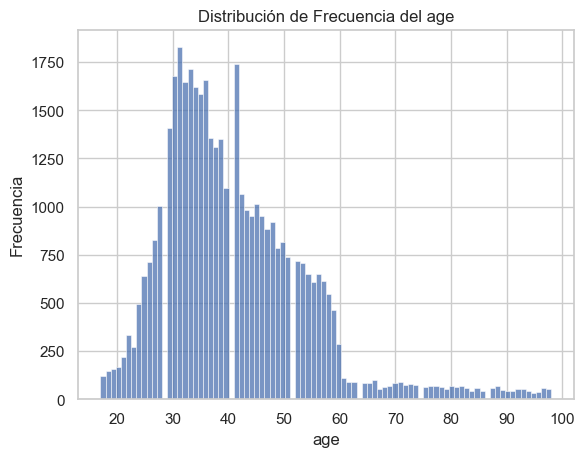

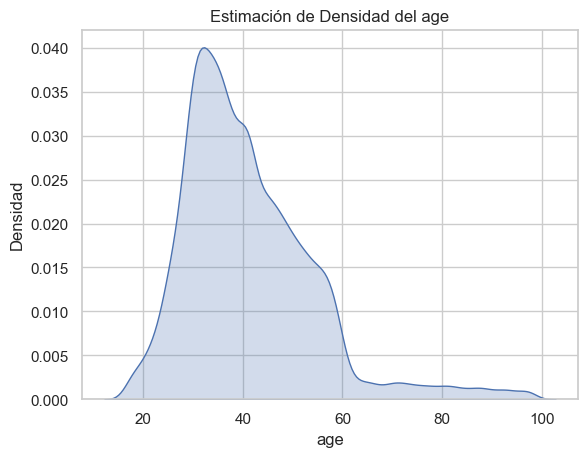

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'age'
sns.histplot(data=df_bank_limpio, x='age', kde=False)
plt.title('Distribución de Frecuencia del age')
plt.xlabel('age')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'age'
sns.kdeplot(df_bank_limpio['age'], fill=True)
plt.title('Estimación de Densidad del age')
plt.xlabel('age')
plt.ylabel('Densidad')
plt.show()

# Columna default

In [97]:
df_bank_limpio['default'].describe()

count    41872.000000
mean         0.207442
std          0.405479
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: default, dtype: float64

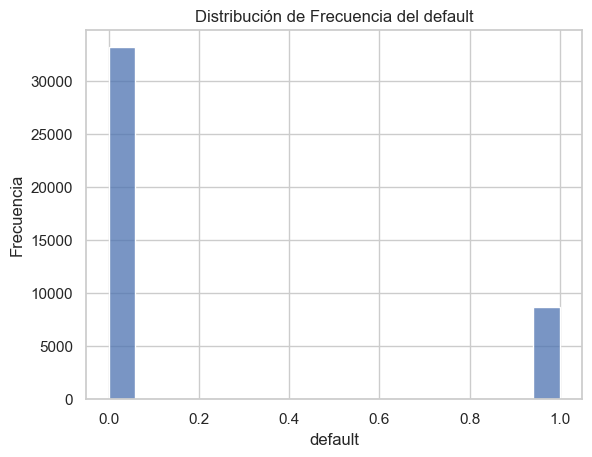

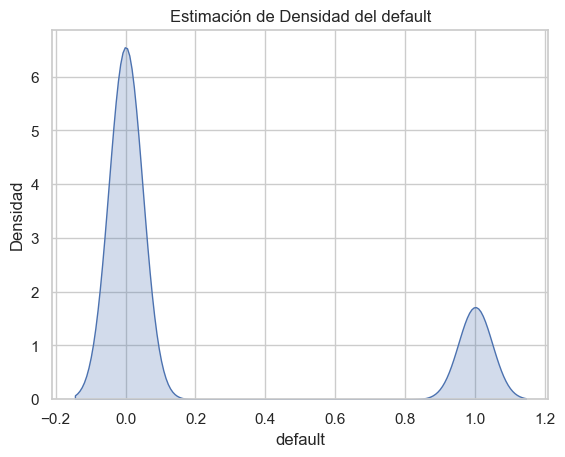

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'default'
sns.histplot(data=df_bank_limpio, x='default', kde=False)
plt.title('Distribución de Frecuencia del default')
plt.xlabel('default')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'default'
sns.kdeplot(df_bank_limpio['default'], fill=True)
plt.title('Estimación de Densidad del default')
plt.xlabel('default')
plt.ylabel('Densidad')
plt.show()

# Columna housing

In [99]:
df_bank_limpio['housing'].describe()

count    40869.000000
mean         0.536348
std          0.498683
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: housing, dtype: float64

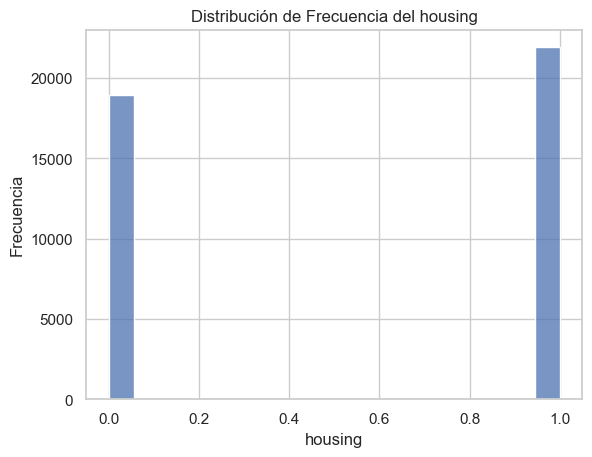

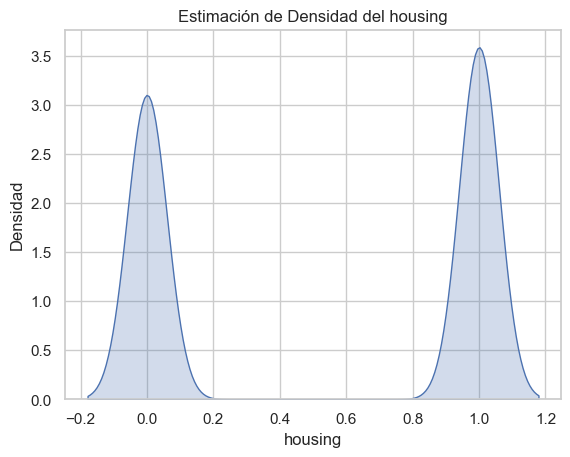

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'housing'
sns.histplot(data=df_bank_limpio, x='housing', kde=False)
plt.title('Distribución de Frecuencia del housing')
plt.xlabel('housing')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'housing'
sns.kdeplot(df_bank_limpio['housing'], fill=True)
plt.title('Estimación de Densidad del housing')
plt.xlabel('housing')
plt.ylabel('Densidad')
plt.show()

# Columna loan

In [101]:
df_bank_limpio['loan'].describe()

count    40869.000000
mean         0.155423
std          0.362312
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: loan, dtype: float64

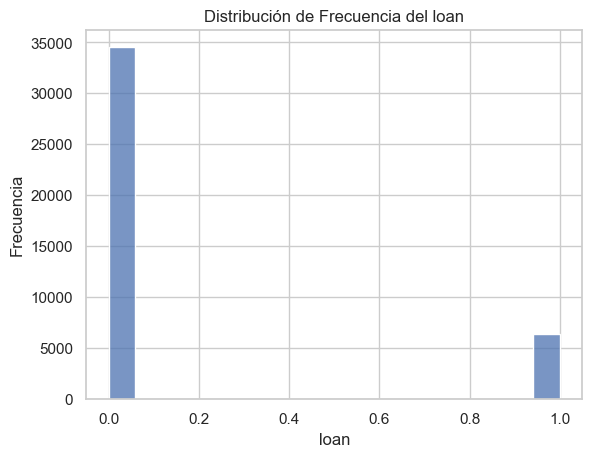

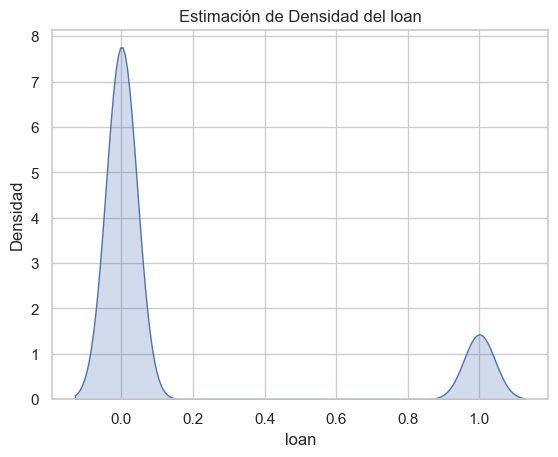

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'loan'
sns.histplot(data=df_bank_limpio, x='loan', kde=False)
plt.title('Distribución de Frecuencia del loan')
plt.xlabel('loan')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'loan'
sns.kdeplot(df_bank_limpio['loan'], fill=True)
plt.title('Estimación de Densidad del loan')
plt.xlabel('loan')
plt.ylabel('Densidad')
plt.show()

# Columna duration

In [103]:
df_bank_limpio['duration'].describe()

count    41872.000000
mean       257.694569
std        258.901853
min          0.000000
25%        102.000000
50%        179.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

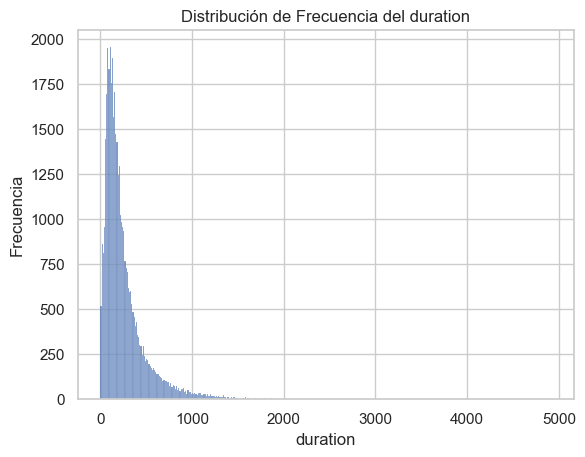

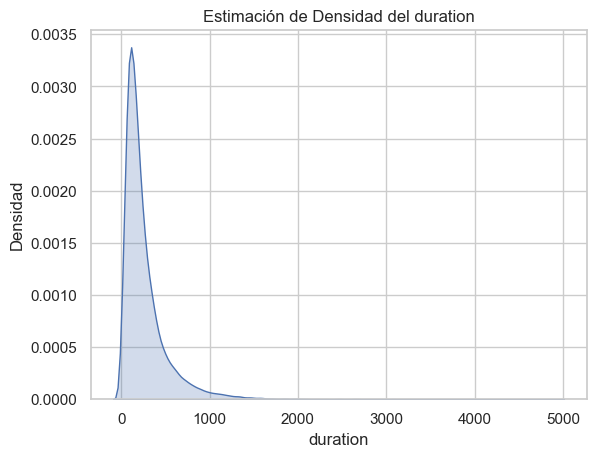

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'duration'
sns.histplot(data=df_bank_limpio, x='duration', kde=False)
plt.title('Distribución de Frecuencia del duration')
plt.xlabel('duration')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'duration'
sns.kdeplot(df_bank_limpio['duration'], fill=True)
plt.title('Estimación de Densidad del duration')
plt.xlabel('duration')
plt.ylabel('Densidad')
plt.show()

# Columna campaign

In [105]:
df_bank_limpio['campaign'].describe()

count    41872.000000
mean         2.562787
std          2.763781
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

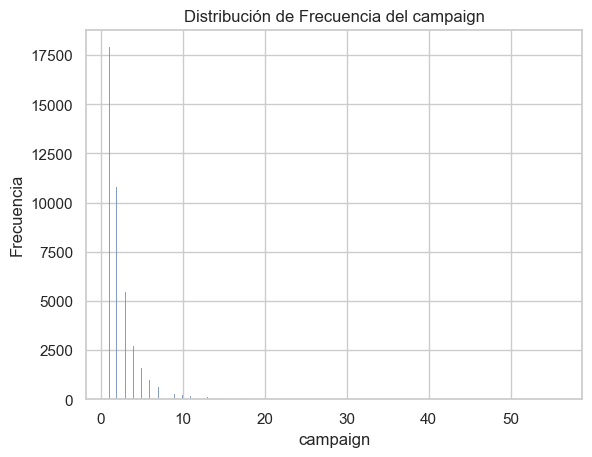

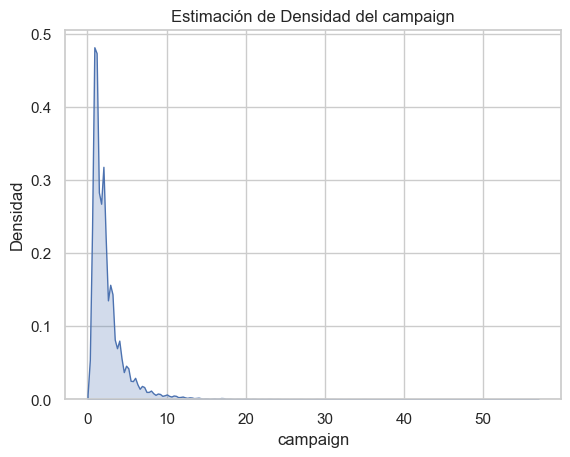

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'campaign'
sns.histplot(data=df_bank_limpio, x='campaign', kde=False)
plt.title('Distribución de Frecuencia del campaign')
plt.xlabel('campaign')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'campaign'
sns.kdeplot(df_bank_limpio['campaign'], fill=True)
plt.title('Estimación de Densidad del campaign')
plt.xlabel('campaign')
plt.ylabel('Densidad')
plt.show()

# Coolumna pdays

In [107]:
df_bank_limpio['pdays'].describe()

count    41872.000000
mean       962.648429
std        186.476162
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

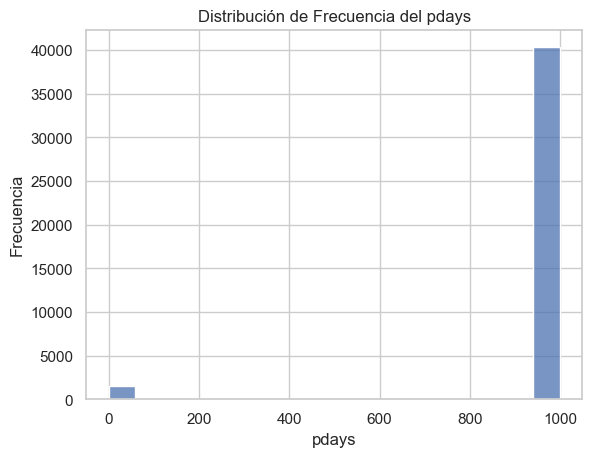

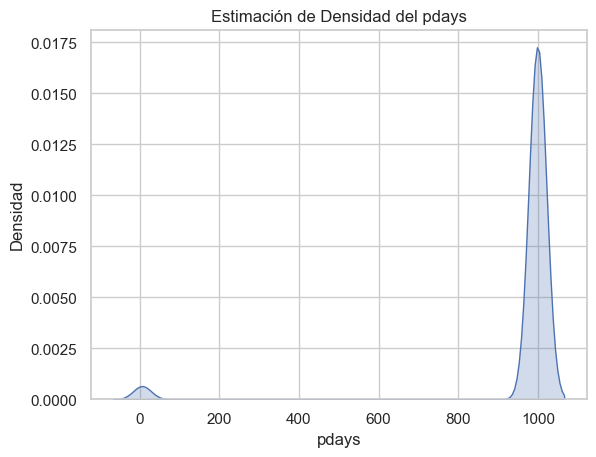

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'pdays'
sns.histplot(data=df_bank_limpio, x='pdays', kde=False)
plt.title('Distribución de Frecuencia del pdays')
plt.xlabel('pdays')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'pdays'
sns.kdeplot(df_bank_limpio['pdays'], fill=True)
plt.title('Estimación de Densidad del pdays')
plt.xlabel('pdays')
plt.ylabel('Densidad')
plt.show()

# Columna previous

In [109]:
df_bank_limpio['previous'].describe()

count    41872.000000
mean         0.174245
std          0.498205
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

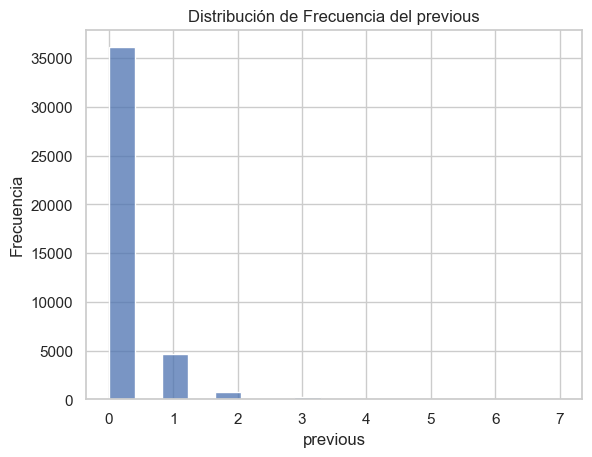

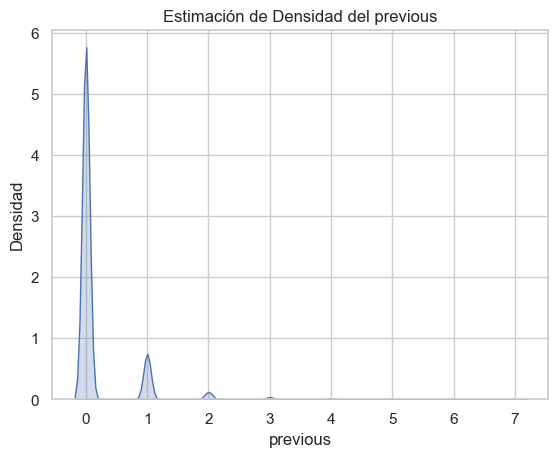

In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'previous'
sns.histplot(data=df_bank_limpio, x='previous', kde=False)
plt.title('Distribución de Frecuencia del previous')
plt.xlabel('previous')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'previous'
sns.kdeplot(df_bank_limpio['previous'], fill=True)
plt.title('Estimación de Densidad del previous')
plt.xlabel('previous')
plt.ylabel('Densidad')
plt.show()

# Columna emp.var.rate

In [111]:
df_bank_limpio['emp.var.rate'].describe()

count    41872.000000
mean         0.076524
std          1.572941
min         -3.400000
25%         -1.800000
50%          1.100000
75%          1.400000
max          1.400000
Name: emp.var.rate, dtype: float64

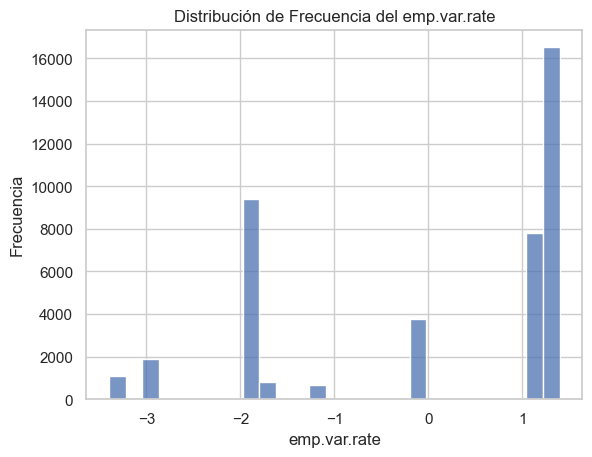

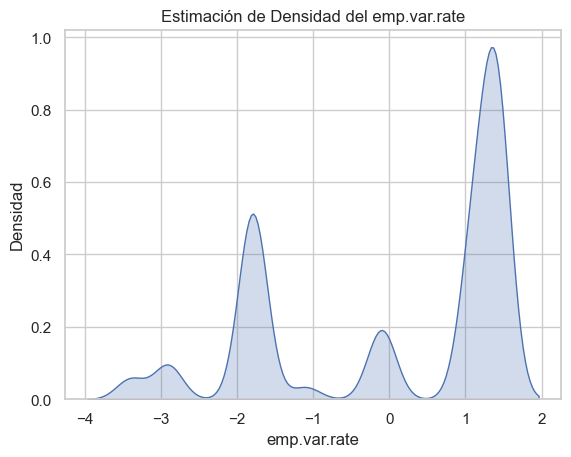

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'emp.var.rate'
sns.histplot(data=df_bank_limpio, x='emp.var.rate', kde=False)
plt.title('Distribución de Frecuencia del emp.var.rate')
plt.xlabel('emp.var.rate')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'emp.var.rate'
sns.kdeplot(df_bank_limpio['emp.var.rate'], fill=True)
plt.title('Estimación de Densidad del emp.var.rate')
plt.xlabel('emp.var.rate')
plt.ylabel('Densidad')
plt.show()

# Columna cons.price.idx

In [113]:
df_bank_limpio['cons.price.idx'].describe()

count    41872.000000
mean        93.573305
std          0.579454
min         92.201000
25%         93.075000
50%         93.749000
75%         93.994000
max         94.767000
Name: cons.price.idx, dtype: float64

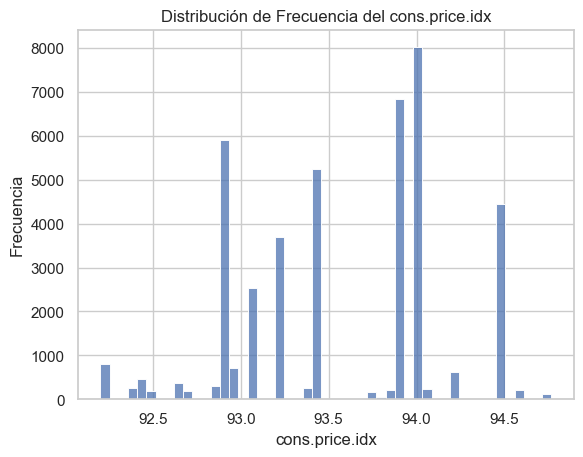

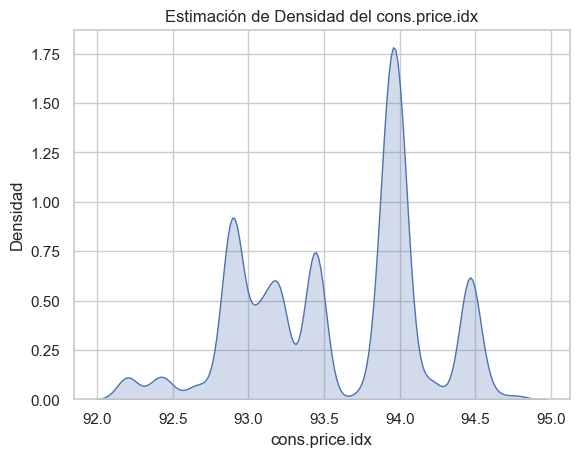

In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'cons.price.idx'
sns.histplot(data=df_bank_limpio, x='cons.price.idx', kde=False)
plt.title('Distribución de Frecuencia del cons.price.idx')
plt.xlabel('cons.price.idx')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'cons.price.idx'
sns.kdeplot(df_bank_limpio['cons.price.idx'], fill=True)
plt.title('Estimación de Densidad del cons.price.idx')
plt.xlabel('cons.price.idx')
plt.ylabel('Densidad')
plt.show()

# Coolumna cons.conf.idx

In [115]:
df_bank_limpio['cons.price.idx'].describe()

count    41872.000000
mean        93.573305
std          0.579454
min         92.201000
25%         93.075000
50%         93.749000
75%         93.994000
max         94.767000
Name: cons.price.idx, dtype: float64

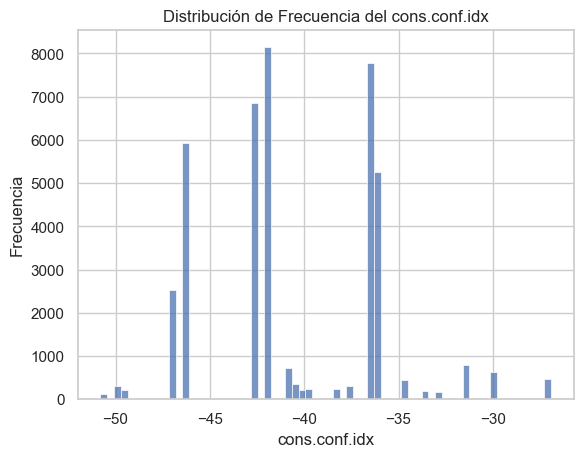

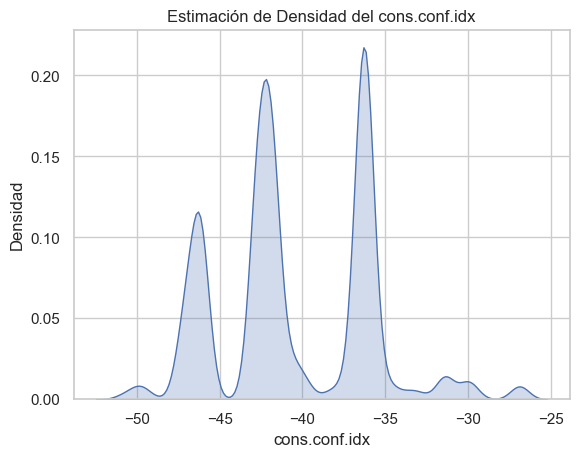

In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'cons.conf.idx'
sns.histplot(data=df_bank_limpio, x='cons.conf.idx', kde=False)
plt.title('Distribución de Frecuencia del cons.conf.idx')
plt.xlabel('cons.conf.idx')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'cons.conf.idx'
sns.kdeplot(df_bank_limpio['cons.conf.idx'], fill=True)
plt.title('Estimación de Densidad del cons.conf.idx')
plt.xlabel('cons.conf.idx')
plt.ylabel('Densidad')
plt.show()

# Coolumna euribor3m

In [117]:
df_bank_limpio['euribor3m'].describe()

count    41872.000000
mean         3.613494
std          1.736180
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64

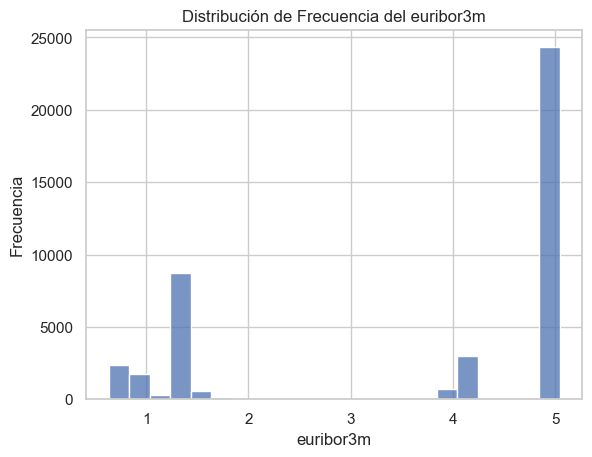

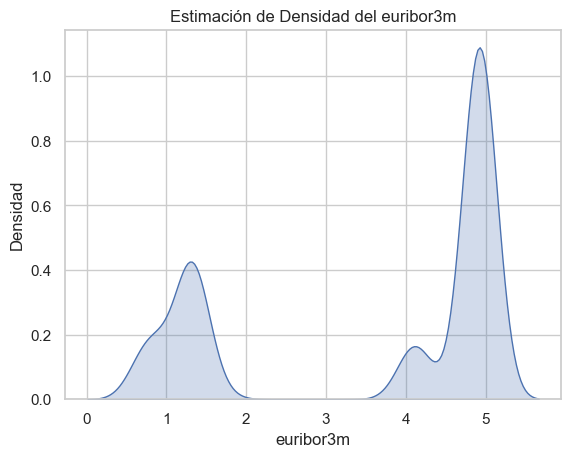

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'euribor3m'
sns.histplot(data=df_bank_limpio, x='euribor3m', kde=False)
plt.title('Distribución de Frecuencia del euribor3m')
plt.xlabel('euribor3m')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'euribor3m'
sns.kdeplot(df_bank_limpio['euribor3m'], fill=True)
plt.title('Estimación de Densidad del euribor3m')
plt.xlabel('euribor3m')
plt.ylabel('Densidad')
plt.show()

# Coolumna nr.employed

In [119]:
df_bank_limpio['nr.employed'].describe()

count    41872.000000
mean      5166.877947
std         72.352829
min       4963.600000
25%       5099.100000
50%       5191.000000
75%       5228.100000
max       5228.100000
Name: nr.employed, dtype: float64

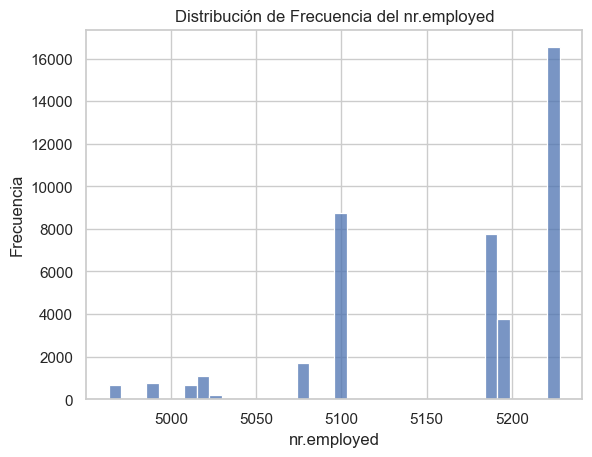

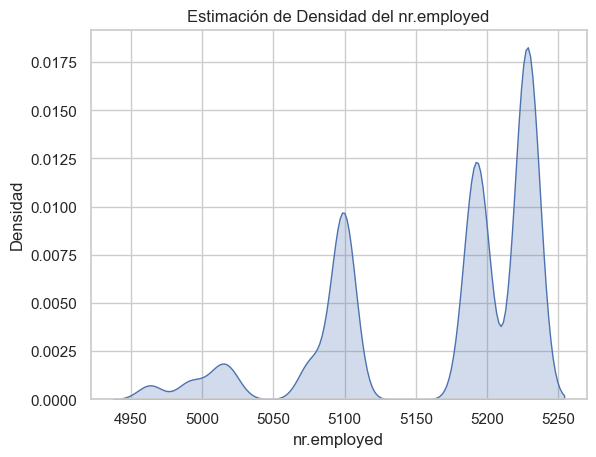

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'nr.employed'
sns.histplot(data=df_bank_limpio, x='nr.employed', kde=False)
plt.title('Distribución de Frecuencia del nr.employed')
plt.xlabel('nr.employed')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'nr.employed'
sns.kdeplot(df_bank_limpio['nr.employed'], fill=True)
plt.title('Estimación de Densidad del nr.employed')
plt.xlabel('nr.employed')
plt.ylabel('Densidad')
plt.show()

# Columna   latitude

In [121]:
df_bank_limpio['latitude'].describe()

count    41872.000000
mean        36.854194
std          7.221253
min         24.396000
25%         30.618750
50%         36.760000
75%         43.098250
max         49.384000
Name: latitude, dtype: float64

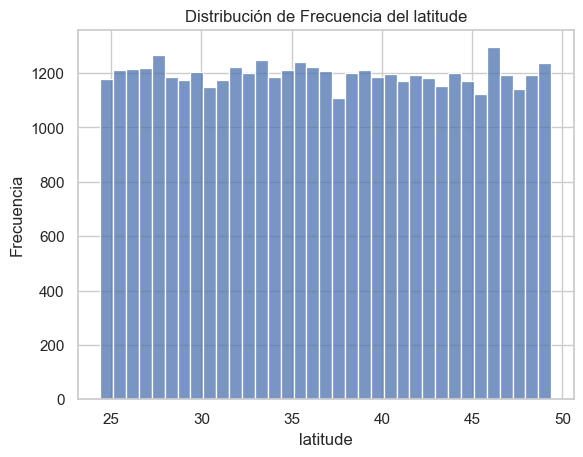

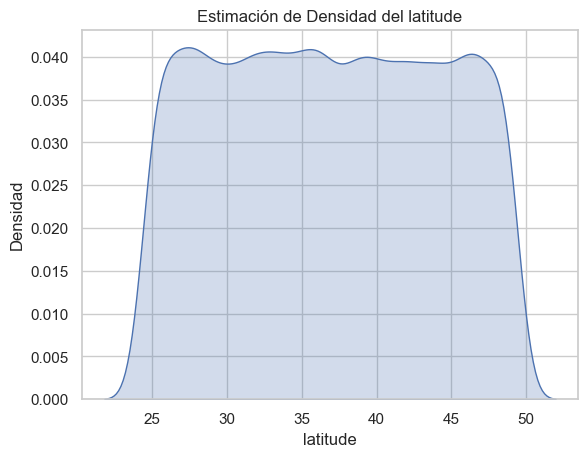

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Trazamos el histograma de la columna 'latitude'
sns.histplot(data=df_bank_limpio, x='latitude', kde=False)
plt.title('Distribución de Frecuencia del latitude')
plt.xlabel('latitude')
plt.ylabel('Frecuencia')
plt.show()

# Trazamos el gráfico de densidad de la columna 'latitude'
sns.kdeplot(df_bank_limpio['latitude'], fill=True)
plt.title('Estimación de Densidad del latitude')
plt.xlabel('latitude')
plt.ylabel('Densidad')
plt.show()

## Descripción de estadísticos y visualización de las distribucioones en columnas de valores cualitativos en el archivo CSV

## Columna job

In [123]:
print(df_bank_limpio['job'].describe())

count      41872
unique        11
top       admin.
freq       10672
Name: job, dtype: object


In [124]:
print(df_bank_limpio['job'].value_counts())

admin.           10672
blue-collar       9497
technician        6897
services          4062
management        3003
retired           1753
entrepreneur      1496
self-employed     1464
housemaid         1103
unemployed        1043
student            882
Name: job, dtype: int64


In [125]:
porcentaje_trabajos = df_bank_limpio['job'].value_counts(normalize=True) * 100
print("\nPorcentaje:")
print(porcentaje_trabajos)


Porcentaje:
admin.           25.487199
blue-collar      22.681028
technician       16.471628
services          9.700994
management        7.171857
retired           4.186569
entrepreneur      3.572793
self-employed     3.496370
housemaid         2.634219
unemployed        2.490925
student           2.106420
Name: job, dtype: float64


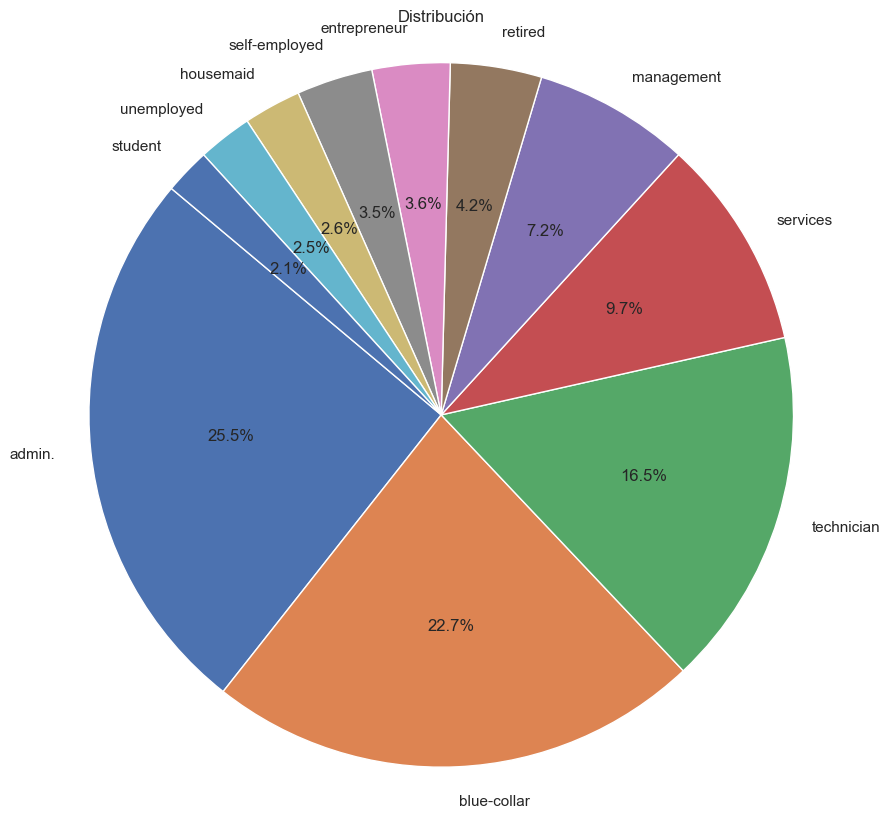

In [126]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'df_bank_limpio' es tu DataFrame y ya está cargado

# 1. Obtener el conteo de frecuencia de la columna 'job'
conteo_jobs = df_bank_limpio['job'].value_counts()

# 2. Obtener las etiquetas (nombres de los trabajos)
etiquetas = conteo_jobs.index

# 3. Obtener los tamaños (el conteo de cada trabajo)
tamaños = conteo_jobs.values

# 4. Crear la figura y el gráfico
plt.figure(figsize=(10, 10))
plt.pie(tamaños, labels=etiquetas, autopct='%1.1f%%', startangle=140)

# 5. Agregar un título
plt.title('Distribución')

# 6. Asegurar que el gráfico sea un círculo perfecto
plt.axis('equal')

# 7. Mostrar el gráfico
plt.show()

## Columna marital

In [127]:
print(df_bank_limpio['marital'].describe())

count       41872
unique          3
top       married
freq        25322
Name: marital, dtype: object


In [128]:
print(df_bank_limpio['marital'].value_counts())

married     25322
single      11838
divorced     4712
Name: marital, dtype: int64


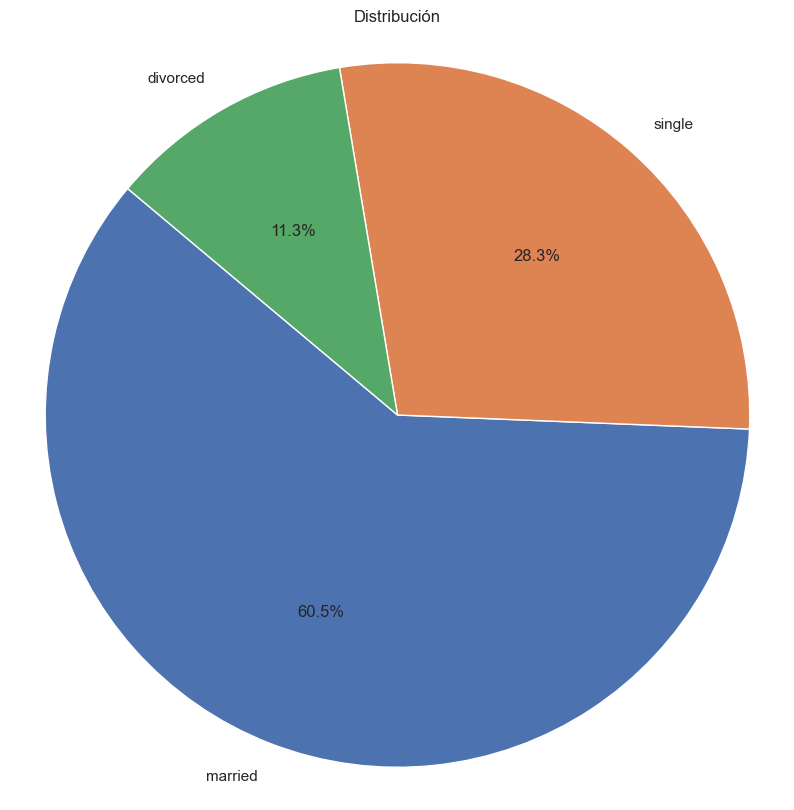

In [129]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'df_bank_limpio' es tu DataFrame y ya está cargado

# 1. Obtener el conteo de frecuencia de la columna 'marital'
conteo_maritals = df_bank_limpio['marital'].value_counts()

# 2. Obtener las etiquetas (nombres de los trabajos)
etiquetas = conteo_maritals.index

# 3. Obtener los tamaños (el conteo de cada trabajo)
tamaños = conteo_maritals.values

# 4. Crear la figura y el gráfico
plt.figure(figsize=(10, 10))
plt.pie(tamaños, labels=etiquetas, autopct='%1.1f%%', startangle=140)

# 5. Agregar un título
plt.title('Distribución')

# 6. Asegurar que el gráfico sea un círculo perfecto
plt.axis('equal')

# 7. Mostrar el gráfico
plt.show()

## Columna education

In [130]:
print(df_bank_limpio['education'].describe())

count                 40235
unique                    7
top       university.degree
freq                  12423
Name: education, dtype: object


In [131]:
print(df_bank_limpio['education'].value_counts())

university.degree      12423
high.school             9718
basic.9y                6184
professional.course     5350
basic.4y                4223
basic.6y                2319
illiterate                18
Name: education, dtype: int64


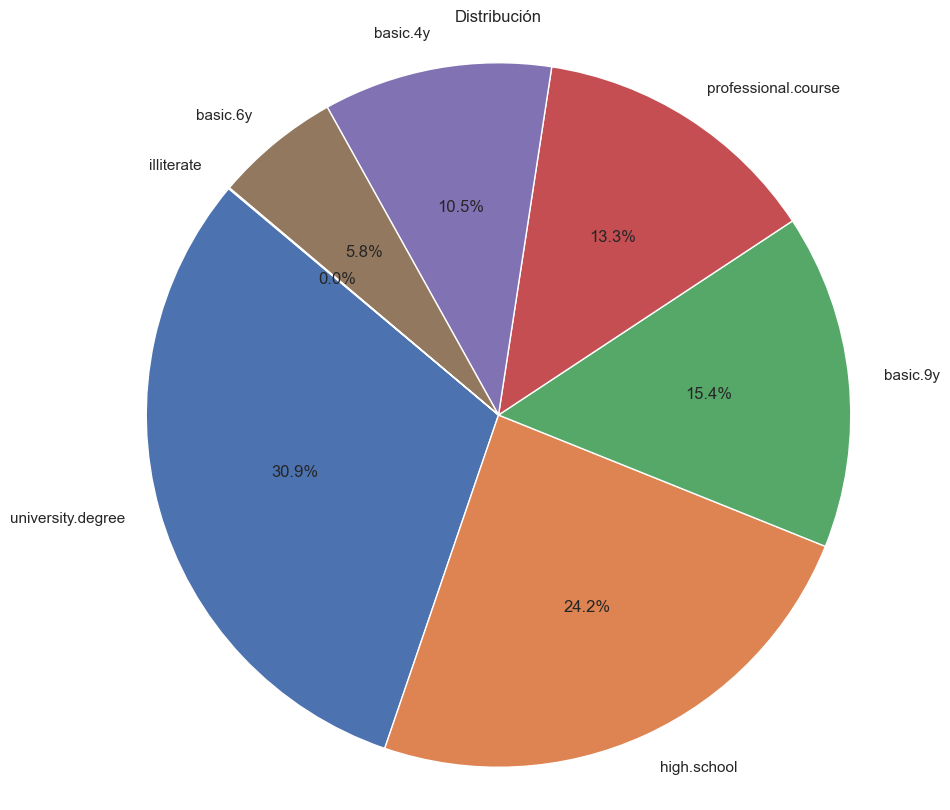

In [132]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'df_bank_limpio' es tu DataFrame y ya está cargado

# 1. Obtener el conteo de frecuencia de la columna 'education'
conteo_educations = df_bank_limpio['education'].value_counts()

# 2. Obtener las etiquetas (nombres de los trabajos)
etiquetas = conteo_educations.index

# 3. Obtener los tamaños (el conteo de cada trabajo)
tamaños = conteo_educations.values

# 4. Crear la figura y el gráfico
plt.figure(figsize=(10, 10))
plt.pie(tamaños, labels=etiquetas, autopct='%1.1f%%', startangle=140)

# 5. Agregar un título
plt.title('Distribución')

# 6. Asegurar que el gráfico sea un círculo perfecto
plt.axis('equal')

# 7. Mostrar el gráfico
plt.show()

## Columna contact

In [133]:
print(df_bank_limpio['contact'].describe())

count        41872
unique           2
top       cellular
freq         26704
Name: contact, dtype: object


In [134]:
print(df_bank_limpio['contact'].value_counts())

cellular     26704
telephone    15168
Name: contact, dtype: int64


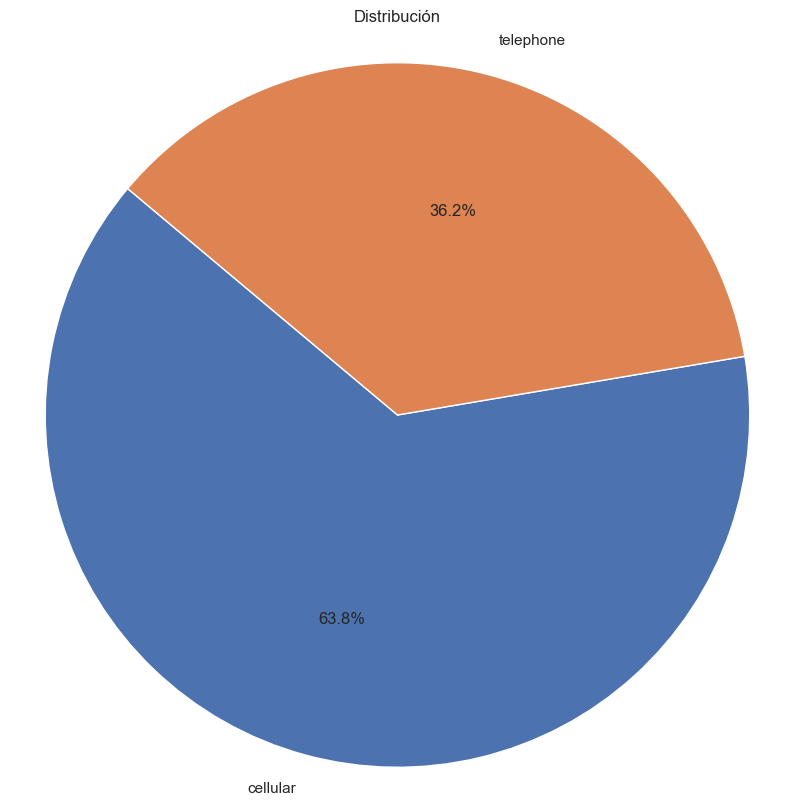

In [135]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'df_bank_limpio' es tu DataFrame y ya está cargado

# 1. Obtener el conteo de frecuencia de la columna 'contact'
conteo_contacts = df_bank_limpio['contact'].value_counts()

# 2. Obtener las etiquetas (nombres de los trabajos)
etiquetas = conteo_contacts.index

# 3. Obtener los tamaños (el conteo de cada trabajo)
tamaños = conteo_contacts.values

# 4. Crear la figura y el gráfico
plt.figure(figsize=(10, 10))
plt.pie(tamaños, labels=etiquetas, autopct='%1.1f%%', startangle=140)

# 5. Agregar un título
plt.title('Distribución')

# 6. Asegurar que el gráfico sea un círculo perfecto
plt.axis('equal')

# 7. Mostrar el gráfico
plt.show()

## Columna y (si está suscrito)

In [136]:
print(df_bank_limpio['y'].describe())

count     41872
unique        2
top          no
freq      37163
Name: y, dtype: object


In [137]:
print(df_bank_limpio['y'].value_counts())

no     37163
yes     4709
Name: y, dtype: int64


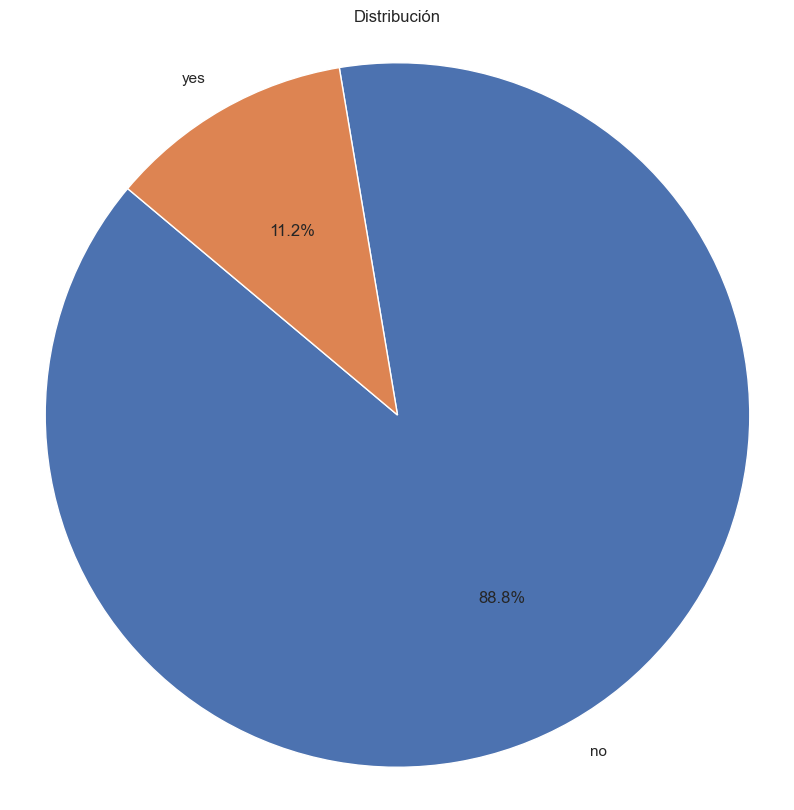

In [138]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'df_bank_limpio' es tu DataFrame y ya está cargado

# 1. Obtener el conteo de frecuencia de la columna 'y'
conteo_ys = df_bank_limpio['y'].value_counts()

# 2. Obtener las etiquetas (nombres de los trabajos)
etiquetas = conteo_ys.index

# 3. Obtener los tamaños (el conteo de cada trabajo)
tamaños = conteo_ys.values

# 4. Crear la figura y el gráfico
plt.figure(figsize=(10, 10))
plt.pie(tamaños, labels=etiquetas, autopct='%1.1f%%', startangle=140)

# 5. Agregar un título
plt.title('Distribución')

# 6. Asegurar que el gráfico sea un círculo perfecto
plt.axis('equal')

# 7. Mostrar el gráfico
plt.show()

## Matriz de correlaciones


=== MATRIZ DE CORRELACIONES ===


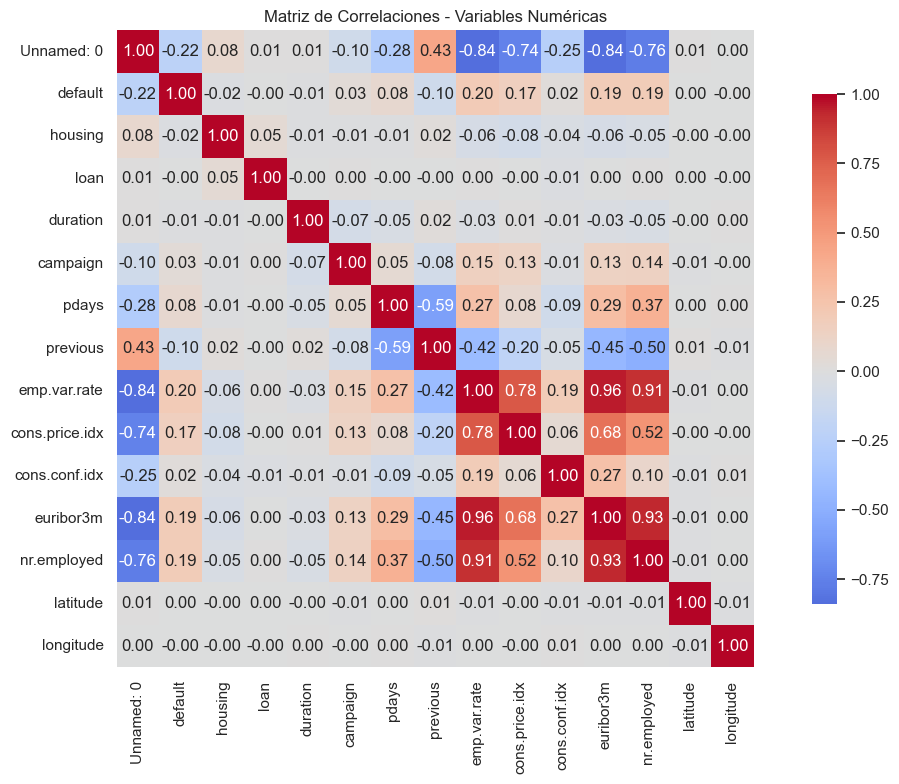

In [139]:
# === MATRIZ DE CORRELACIONES ===
print("\n=== MATRIZ DE CORRELACIONES ===")

# Seleccionar variables numéricas
numeric_cols = df_bank_limpio.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_bank_limpio[numeric_cols].corr()

# Crear heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlaciones - Variables Numéricas')
plt.tight_layout()
plt.show()

## Análisis bivariado


=== ANÁLISIS BIVARIADO ===


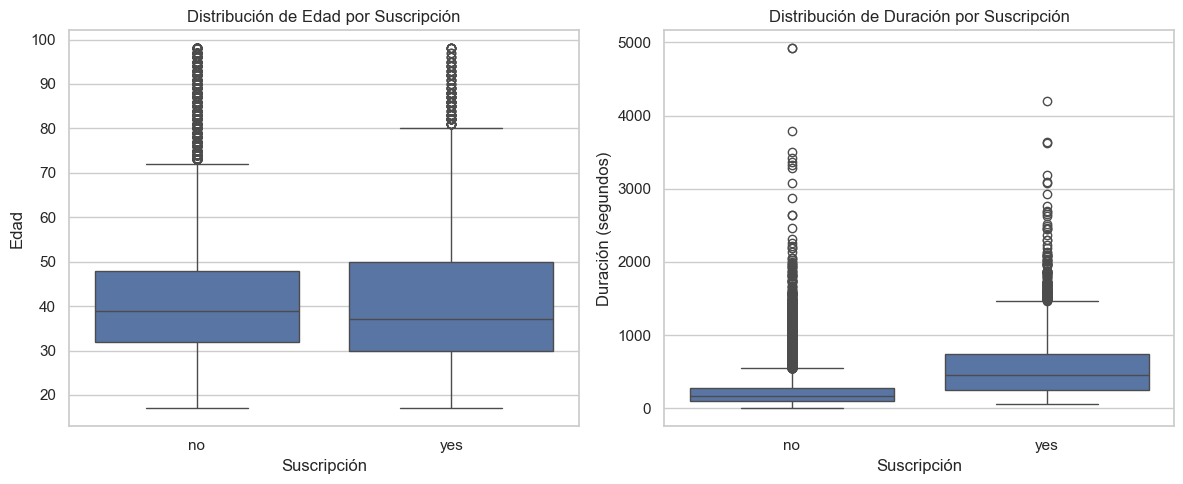

In [140]:
# === ANÁLISIS BIVARIADO ===
print("\n=== ANÁLISIS BIVARIADO ===")

# Relación entre edad y suscripción
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_bank_limpio, x='y', y='age')
plt.title('Distribución de Edad por Suscripción')
plt.xlabel('Suscripción')
plt.ylabel('Edad')

# Relación entre duración y suscripción
plt.subplot(1, 2, 2)
sns.boxplot(data=df_bank_limpio, x='y', y='duration')
plt.title('Distribución de Duración por Suscripción')
plt.xlabel('Suscripción')
plt.ylabel('Duración (segundos)')

plt.tight_layout()
plt.show()

# Rellaciones del conjunto de hojas del Excel

In [141]:
#Primero aunamos todas las hojas, así tenemos el conjunto completo
import pandas as pd
import matplotlib.pyplot as plt

# Concatenar los DataFrames
df_completo_hojas = pd.concat([df_2012, df_2013, df_2014], ignore_index=True)

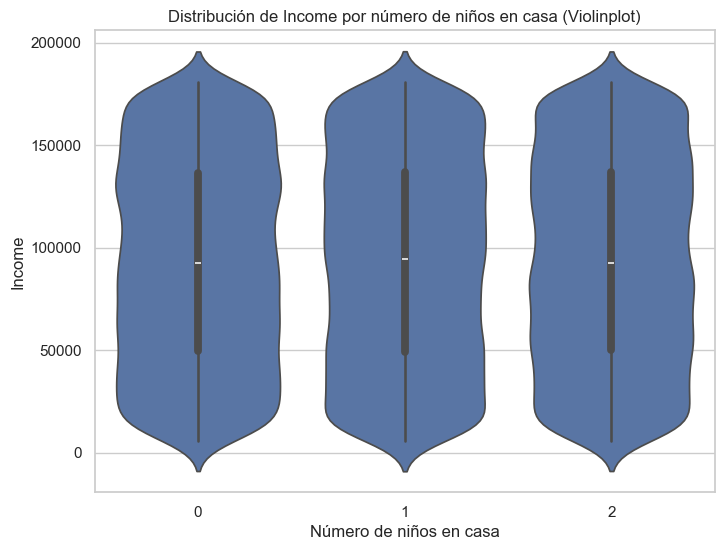

In [142]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Kidhome', y='Income', data=df_completo_hojas)
plt.title('Distribución de Income por número de niños en casa (Violinplot)')
plt.xlabel('Número de niños en casa')
plt.ylabel('Income')
plt.show()

#Vemos que todo es homoogeneo, tanto el vallor medio como lla distribucion de hijos por ingresos, muy semejantes entre si, asi los ingresos no afectan a la cantidad de hijos

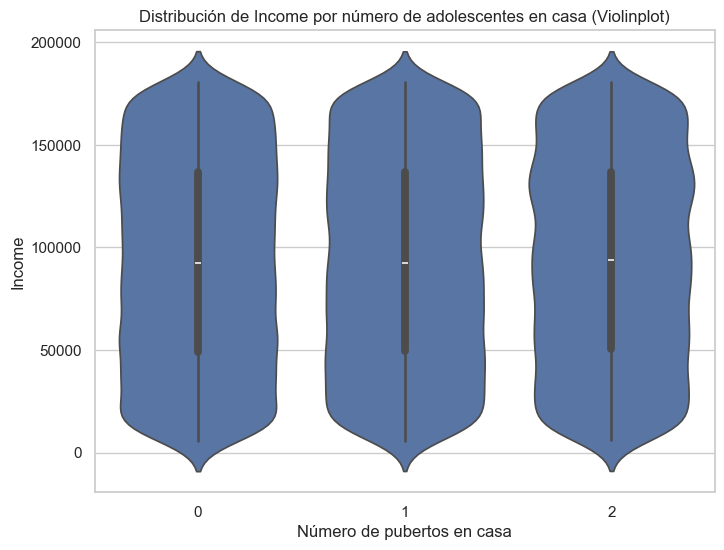

In [143]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Teenhome', y='Income', data=df_completo_hojas)
plt.title('Distribución de Income por número de adolescentes en casa (Violinplot)')
plt.xlabel('Número de pubertos en casa')
plt.ylabel('Income')
plt.show()

#Vemos que todo es homoogeneo, tanto el vallor medio como lla distribucion de hijos por ingresos, muy semejantes entre si, asi los ingresos no afectan a la cantidad de hijos